In [3]:
import pathlib

import numpy as np
import pandas as pd
import shapely
import antimeridian
import geopandas as gpd
import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import requests
import fsspec
import earthaccess
auth = earthaccess.login()
from pystac_client import Client

In [ ]:
tracking_path = pathlib.Path("/gws/ssde/j25a/esaclim/will/orcestra_linked")

In [ ]:
tracking_files = sorted(list(tracking_path.rglob("detected_dccs_*.nc")))

In [ ]:
len(tracking_files)

In [ ]:
tracking_files[8]

In [ ]:
tracks_ds = xr.open_dataset(tracking_files[8])

In [ ]:
tracks_ds

In [ ]:
plt.scatter(tracks_ds.longitude, tracks_ds.latitude)

In [ ]:
wh = np.logical_and(np.isfinite(tracks_ds.longitude), np.isfinite(tracks_ds.latitude))

In [ ]:
from scipy.spatial import ConvexHull

In [ ]:
convex_inds = ConvexHull(
    np.stack((tracks_ds.longitude.values[wh.values], tracks_ds.latitude.values[wh.values]), axis=1)
).vertices

In [12]:
antimeridian.fix_polygon

<function antimeridian._implementation.fix_polygon(polygon: 'Polygon', *, force_north_pole: 'bool' = False, force_south_pole: 'bool' = False, fix_winding: 'bool | None' = None, great_circle: 'bool' = True) -> 'Polygon | MultiPolygon'>

In [13]:
tracking_bounds = shapely.Polygon(
    list(zip(
        tracks_ds.longitude.values[wh.values][convex_inds], 
        tracks_ds.latitude.values[wh.values][convex_inds], 
    ))
)

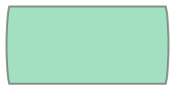

In [14]:
tracking_bounds

In [15]:
tracking_bounds.bounds

(-81.19845598820453, -38.75133157873256, 81.19845598820453, 38.75133157873256)

In [16]:
from pystac_client import Client

catalog_url = 'https://catalog.maap.eo.esa.int/catalogue/'
catalog = Client.open(catalog_url)
EC_COLLECTION = ['EarthCAREL2Validated_MAAP']

import requests
import fsspec

CREDENTIALS_FILE = (pathlib.Path.home() / "credentials.txt" ).resolve()   # Insert the .txt path
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

def load_credentials(file_path=CREDENTIALS_FILE):
    """Read key-value pairs from a credentials file into a dictionary."""
    creds = {}
    if not file_path.exists():
        raise FileNotFoundError(f"Credentials file not found: {file_path}")
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            creds[key.strip()] = value.strip()
    return creds


# --- ESA MAAP API ---

def get_token():
    """Use OFFLINE_TOKEN to fetch a short-lived access token."""
    creds = load_credentials()

    OFFLINE_TOKEN = creds.get("OFFLINE_TOKEN")
    CLIENT_ID = creds.get("CLIENT_ID")
    CLIENT_SECRET = creds.get("CLIENT_SECRET")
    # print(CLIENT_SECRET)

    if not all([OFFLINE_TOKEN, CLIENT_ID, CLIENT_SECRET]):
        raise ValueError("Missing OFFLINE_TOKEN, CLIENT_ID, or CLIENT_SECRET in credentials file")

    url = "https://iam.maap.eo.esa.int/realms/esa-maap/protocol/openid-connect/token"
    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
        "grant_type": "refresh_token",
        "refresh_token": OFFLINE_TOKEN,
        "scope": "offline_access openid"
    }

    response = requests.post(url, data=data)
    response.raise_for_status()

    response_json = response.json()
    access_token = response_json.get('access_token')

    if not access_token:
        raise RuntimeError("Failed to retrieve access token from IAM response")

    return access_token

token = get_token()
fs = fsspec.filesystem(
    "https", 
    headers={"Authorization": f"Bearer {token}"}, 
    **io_params["fsspec_params"], 
)

from contextlib import contextmanager

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()


In [17]:
search = catalog.search(
    collections=EC_COLLECTION, 
    datetime=("2024-08-10", "2024-09-30"), 
    bbox=tracking_bounds.bounds, 
    filter="(productType = 'CPR_FMR_2A')",# or (productType = 'CPR_CD__2A')",
    method = 'GET', # This is necessary 
)

df = pd.DataFrame(
    data={"stac":list(search.items())}
)

df["granule"] = [f.id[-6:] for f in df.stac]
df["product"] = [f.id[9:19] for f in df.stac]
df["baseline"] = [f.id[6:8] for f in df.stac]
df["date"] = [
    pd.to_datetime(f.id[20:35], format="%Y%m%dT%H%M%S") for f in df.stac
]
df["enclosure_h5"] = [f.assets.get('enclosure_h5').href for f in df.stac]
df = df.sort_values(["date", "product"]).reset_index(drop=True)

In [18]:
len(df)

1989

In [19]:
[f.id for f in df.stac][0][6:8]

'BA'

In [20]:
df["enclosure_h5"] = [
    row["stac"].assets.get('enclosure_h5').href for idx, row in df.iterrows()
]

In [21]:
df

,stac,granule,product,baseline,date,enclosure_h5
0,<Item id=ECA_EXBA_CPR_FMR_2A_20240810T001450Z_...,01136H,CPR_FMR_2A,BA,2024-08-10 00:14:50,https://catalog.maap.eo.esa.int/data/earthcare...
1,<Item id=ECA_EXBA_CPR_FMR_2A_20240810T002639Z_...,01137A,CPR_FMR_2A,BA,2024-08-10 00:26:39,https://catalog.maap.eo.esa.int/data/earthcare...
2,<Item id=ECA_EXBA_CPR_FMR_2A_20240810T003815Z_...,01137B,CPR_FMR_2A,BA,2024-08-10 00:38:15,https://catalog.maap.eo.esa.int/data/earthcare...
3,<Item id=ECA_EXBA_CPR_FMR_2A_20240810T014726Z_...,01137H,CPR_FMR_2A,BA,2024-08-10 01:47:26,https://catalog.maap.eo.esa.int/data/earthcare...
4,<Item id=ECA_EXBA_CPR_FMR_2A_20240810T015915Z_...,01138A,CPR_FMR_2A,BA,2024-08-10 01:59:15,https://catalog.maap.eo.esa.int/data/earthcare...
...,...,...,...,...,...,...
1984,<Item id=ECA_EXBA_CPR_FMR_2A_20240930T211927Z_...,01944A,CPR_FMR_2A,BA,2024-09-30 21:19:27,https://catalog.maap.eo.esa.int/data/earthcare...
1985,<Item id=ECA_EXBA_CPR_FMR_2A_20240930T213102Z_...,01944B,CPR_FMR_2A,BA,2024-09-30 21:31:02,https://catalog.maap.eo.esa.int/data/earthcare...
1986,<Item id=ECA_EXBA_CPR_FMR_2A_20240930T224010Z_...,01944H,CPR_FMR_2A,BA,2024-09-30 22:40:10,https://catalog.maap.eo.esa.int/data/earthcare...
1987,<Item id=ECA_EXBA_CPR_FMR_2A_20240930T225159Z_...,01945A,CPR_FMR_2A,BA,2024-09-30 22:51:59,https://catalog.maap.eo.esa.int/data/earthcare...


In [22]:
gdf = gpd.GeoDataFrame(
    df.drop("stac", axis=1), 
    geometry=[
        antimeridian.fix_line_string(
            shapely.LineString(row["stac"].geometry["coordinates"]), 
            great_circle=True,
        )
        for idx, row in df.iterrows()
    ], 
    crs="EPSG:4326"
)

In [23]:
gdf

,granule,product,baseline,date,enclosure_h5,geometry
0,01136H,CPR_FMR_2A,BA,2024-08-10 00:14:50,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (20.80746 -67.53702, 16.98106 -62.6..."
1,01137A,CPR_FMR_2A,BA,2024-08-10 00:26:39,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (26.75948 -22.54205, 25.74697 -17.5..."
2,01137B,CPR_FMR_2A,BA,2024-08-10 00:38:15,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (18.07282 22.4563, 16.99165 27.5241..."
3,01137H,CPR_FMR_2A,BA,2024-08-10 01:47:26,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (-2.32347 -67.55599, -6.15538 -62.6..."
4,01138A,CPR_FMR_2A,BA,2024-08-10 01:59:15,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (3.61402 -22.56574, 2.59974 -17.569..."
...,...,...,...,...,...,...
1984,01944A,CPR_FMR_2A,BA,2024-09-30 21:19:27,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (73.22546 -22.43955, 72.21481 -17.4..."
1985,01944B,CPR_FMR_2A,BA,2024-09-30 21:31:02,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (64.54563 22.52792, 63.46402 27.594..."
1986,01944H,CPR_FMR_2A,BA,2024-09-30 22:40:10,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (44.15182 -67.50772, 40.33208 -62.6..."
1987,01945A,CPR_FMR_2A,BA,2024-09-30 22:51:59,https://catalog.maap.eo.esa.int/data/earthcare...,"LINESTRING (50.10142 -22.50163, 49.08863 -17.5..."


In [24]:
[df.granule.tolist() for _, df in gdf.groupby((gdf.date.diff() > np.timedelta64(15, "m")).cumsum())]

[['01136H', '01137A', '01137B'],
 ['01137H', '01138A', '01138B'],
 ['01138H', '01139A', '01139B'],
 ['01139H', '01140A', '01140B'],
 ['01141A', '01141B'],
 ['01141D', '01141E', '01141F'],
 ['01142D', '01142E', '01142F'],
 ['01143D', '01143E', '01143F'],
 ['01144D', '01144E', '01144F'],
 ['01145D', '01145E', '01145F'],
 ['01146D', '01146E', '01146F'],
 ['01147D', '01147E', '01147F'],
 ['01148D'],
 ['01149H', '01150A', '01150B'],
 ['01150H', '01151A', '01151B'],
 ['01151H', '01152A', '01152B'],
 ['01152H', '01153A', '01153B'],
 ['01153H', '01154A', '01154B'],
 ['01154H', '01155A', '01155B'],
 ['01155H', '01156A', '01156B'],
 ['01156F'],
 ['01157A'],
 ['01157D', '01157E', '01157F'],
 ['01158D', '01158E', '01158F'],
 ['01159D', '01159E', '01159F'],
 ['01160D', '01160E', '01160F'],
 ['01161D', '01161E', '01161F'],
 ['01162D', '01162E', '01162F'],
 ['01163D', '01163E', '01163F'],
 ['01164H'],
 ['01165H', '01166A', '01166B'],
 ['01166H', '01167A', '01167B'],
 ['01167H', '01168A', '01168B'],
 

In [25]:
io_params = {
    "fsspec_params": {
        "cache_type": "blockcache",
        "block_size": 8 * 1024 * 1024
    },
    "h5py_params": {
        "driver_kwds": {
            "rdcc_nbytes": 8 * 1024 * 1024
        }
    }
}

def search_ec_filename(product, orbit, frame):
    search = catalog.search(
        collections=EC_COLLECTION, 
        filter=f"(productType = '{product}') and orbitNumber = {orbit} and frame = '{frame}'", # For example filter by product type and orbitNumber. Use boolean logic for multi-filter queries
        method = 'GET', # This is necessary 
        max_items=1  # Adjust as needed, given the large amount of products it is recommended to set a limit if especially if you display results in pandas dataframe or similiar
    )
    items = list(search.items())
    if len(items):
        return items[0].assets.get('enclosure_h5').href

    raise ValueError(
        f'No EarthCARE files found for search {product=}, {orbit=}, {frame=}'
    )

from contextlib import contextmanager

@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        ds = xr.open_dataset(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
        yield ds
    finally:
        f.close()
        ds.close()

def select_vars(ds, data_vars):
    return ds.set_coords(["time", "latitude", "longitude", "height"])[data_vars]

In [26]:
products = [
    "AC__TC__2B",
    "ACM_CAP_2B", 
    "ACM_COM_2B", 
    "ACM_RT__2B", 
    "ALL_DF__2B", 
    "ATL_EBD_2A", 
    "CPR_CD__2A", 
    "CPR_FMR_2A", 
]

In [27]:
filenames = [search_ec_filename(product, "01944", "H") for product in products]

In [28]:
from IPython.display import display

for product, filename in zip(products, filenames):
    print(product)
    display(
        xr.open_dataset(
            fs.open(filename), 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        )
    )

AC__TC__2B


<xarray.Dataset> Size: 25MB
Dimensions:                                             (along_track: 5344,
                                                         JSG_height: 242)
Dimensions without coordinates: along_track, JSG_height
Data variables: (12/21)
    time                                                (along_track) datetime64[ns] 43kB ...
    latitude                                            (along_track) float64 43kB ...
    longitude                                           (along_track) float64 43kB ...
    geoid_offset                                        (along_track) float64 43kB ...
    elevation                                           (along_track) float32 21kB ...
    height                                              (along_track, JSG_height) float32 5MB ...
    ...                                                  ...
    CPR_ATLID_status                                    (along_track, JSG_height) int8 1MB ...
    CPR_ATLID_low_resolution_status                     (along_track, JSG_height) int8 1MB ...
    CPR_ATLID_medium_resolution_status                  (along_track, JSG_height) int8 1MB ...
    quality_status                                      (along_track, JSG_height) int8 1MB ...
    quality_low_resolution_status                       (along_track, JSG_height) int8 1MB ...
    quality_medium_resolution_status                    (along_track, JSG_height) int8 1MB ...

ACM_CAP_2B


<xarray.Dataset> Size: 590MB
Dimensions:                                                         (
                                                                     along_track: 5204,
                                                                     JSG_height: 242,
                                                                     MSI_longwave_channel: 3,
                                                                     MSI_shortwave_channel: 1)
Dimensions without coordinates: along_track, JSG_height, MSI_longwave_channel,
                                MSI_shortwave_channel
Data variables: (12/192)
    time                                                            (along_track) datetime64[ns] 42kB ...
    latitude                                                        (along_track) float64 42kB ...
    longitude                                                       (along_track) float64 42kB ...
    height                                                          (along_track, JSG_height) float32 5MB ...
    geoid_offset                                                    (along_track) float32 21kB ...
    elevation                                                       (along_track) float32 21kB ...
    ...                                                              ...
    MSI_shortwave_observation_variable_count                        (along_track) int32 21kB ...
    MSI_shortwave_cost_function                                     (along_track) float32 21kB ...
    MSI_shortwave_wavelength                                        (MSI_shortwave_channel) float32 4B ...
    MSI_shortwave_albedo_forward                                    (along_track, MSI_shortwave_channel) float32 21kB ...
    MSI_shortwave_albedo                                            (along_track, MSI_shortwave_channel) float32 21kB ...
    MSI_shortwave_albedo_assimilation_status                        (along_track) int8 5kB ...

ACM_COM_2B


...

<xarray.Dataset> Size: 273MB
Dimensions:                                                         (
                                                                     along_track: 5344,
                                                                     JSG_height: 242,
                                                                     layer: 25,
                                                                     n_state: 351)
Dimensions without coordinates: along_track, JSG_height, layer, n_state
Data variables: (12/66)
    medium_resolution_number_of_joint_standard_grid_pixels          float32 4B ...
    low_resolution_number_of_joint_standard_grid_pixels             float32 4B ...
    joint_standard_grid_index                                       (along_track) float64 43kB ...
    latitude                                                        (along_track) float64 43kB ...
    longitude                                                       (along_track) float64 43kB ...
    time                                                            (along_track) datetime64[ns] 43kB ...
    ...                                                              ...
    lidar_ratio_355nm_low_resolution_error                          (along_track, JSG_height) float32 5MB ...
    retrieved_state_vector                                          (along_track, n_state) float32 8MB ...
    state_vector_prior                                              (along_track, n_state) float32 8MB ...
    state_vector_prior_error                                        (along_track, n_state) float32 8MB ...
    final_chi_square                                                (along_track) float32 21kB ...
    initial_chi_square                                              (along_track) float32 21kB ...

CPR_CD__2A


<xarray.Dataset> Size: 92MB
Dimensions:                                                 (along_track: 4991,
                                                             CPR_height: 218)
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/34)
    time                                                    (along_track) datetime64[ns] 40kB ...
    latitude                                                (along_track) float64 40kB ...
    longitude                                               (along_track) float64 40kB ...
    height                                                  (along_track, CPR_height) float32 4MB ...
    geoid_offset                                            (along_track) float32 20kB ...
    surface_elevation                                       (along_track) float32 20kB ...
    ...                                                      ...
    doppler_velocity_and_spectrum_width_integrated_error    (along_track, CPR_height) float32 4MB ...
    doppler_velocity_and_spectrum_width_integrated_status   (along_track, CPR_height) float32 4MB ...
    doppler_velocity_best_estimate                          (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate                    (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate_error              (along_track, CPR_height) float32 4MB ...
    sedimentation_velocity_best_estimate_status             (along_track, CPR_height) float32 4MB ...

CPR_FMR_2A


<xarray.Dataset> Size: 39MB
Dimensions:                                                  (
                                                              along_track: 4991,
                                                              CPR_height: 218)
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/34)
    time                                                     (along_track) datetime64[ns] 40kB ...
    latitude                                                 (along_track) float64 40kB ...
    longitude                                                (along_track) float64 40kB ...
    height                                                   (along_track, CPR_height) float32 4MB ...
    geoid_offset                                             (along_track) float32 20kB ...
    surface_elevation                                        (along_track) float32 20kB ...
    ...                                                       ...
    path_integrated_attenuation                              (along_track) float32 20kB ...
    path_integrated_attenuation_error                        (along_track) float32 20kB ...
    path_integrated_attenuation_status                       (along_track) int8 5kB ...
    multiple_scattering_status                               (along_track, CPR_height) int8 1MB ...
    profile_class                                            (along_track) int8 5kB ...
    brightness_temperature                                   (along_track) float32 20kB ...

In [29]:
xr.open_datatree(
    fs.open(filenames[0]), 
    engine="h5netcdf", 
    **io_params["h5py_params"],  
    # group="ScienceData"
)

<xarray.DataTree>
Group: /
│   Attributes:
│       Conventions:  CF-1.6
│       title:        
│       history:      20250906T234929.591228 PROC joborder.xml
├── Group: /HeaderData
│   ├── Group: /HeaderData/FixedProductHeader
│   │   │   Dimensions:           ()
│   │   │   Data variables:
│   │   │       File_Name         <U60 240B ...
│   │   │       File_Description  <U1 4B ...
│   │   │       Notes             <U10 40B ...
│   │   │       Mission           <U9 36B ...
│   │   │       File_Class        <U4 16B ...
│   │   │       File_Type         <U10 40B ...
│   │   │       File_Version      <U4 16B ...
│   │   ├── Group: /HeaderData/FixedProductHeader/Source
│   │   │       Dimensions:          ()
│   │   │       Data variables:
│   │   │           System           <U10 40B ...
│   │   │           Creator          <U10 40B ...
│   │   │           Creator_Version  <U4 16B ...
│   │   │           Creation_Date    <U23 92B ...
│   │   └── Group: /HeaderData/FixedProductHeader/Validity_Period
│   │           Dimensions:         ()
│   │           Data variables:
│   │               Validity_Start  <U23 92B ...
│   │               Validity_Stop   <U23 92B ...
│   └── Group: /HeaderData/VariableProductHeader
│       ├── Group: /HeaderData/VariableProductHeader/MainProductHeader
│       │   │   Dimensions:                     ()
│       │   │   Data variables: (12/45)
│       │   │       productName                 <U60 240B ...
│       │   │       originalProductName         <U1 4B ...
│       │   │       missionID                   <U3 12B ...
│       │   │       fileClass                   <U4 16B ...
│       │   │       fileCategory                <U4 16B ...
│       │   │       productType                 <U4 16B ...
│       │   │       ...                          ...
│       │   │       rightAscension              float64 8B ...
│       │   │       meanAnomaly                 float64 8B ...
│       │   │       frameStartTime              <U23 92B ...
│       │   │       frameStopTime               <U23 92B ...
│       │   │       frameStartMargin            float64 8B ...
│       │   │       frameStopMargin             float64 8B ...
│       │   ├── Group: /HeaderData/VariableProductHeader/MainProductHeader/frameStartCoordinates
│       │   │       Dimensions:              ()
│       │   │       Data variables:
│       │   │           geographicLatitude   float32 4B ...
│       │   │           geographicLongitude  float32 4B ...
│       │   └── Group: /HeaderData/VariableProductHeader/MainProductHeader/frameStopCoordinates
│       │           Dimensions:              ()
│       │           Data variables:
│       │               geographicLatitude   float32 4B ...
│       │               geographicLongitude  float32 4B ...
│       └── Group: /HeaderData/VariableProductHeader/SpecificProductHeader
│           │   Dimensions:                  ()
│           │   Data variables:
│           │       InputFileList            <U242 968B ...
│           │       ConfigurationParameters  <U11859 47kB ...
│           └── Group: /HeaderData/VariableProductHeader/SpecificProductHeader/QualityStatistics
└── Group: /ScienceData
        Dimensions:                                             (along_track: 5344,
                                                                 JSG_height: 242)
        Dimensions without coordinates: along_track, JSG_height
        Data variables: (12/21)
            time                                                (along_track) datetime64[ns] 43kB ...
            latitude                                            (along_track) float64 43kB ...
            longitude                                           (along_track) float64 43kB ...
            geoid_offset                                        (along_track) float64 43kB ...
            elevation                                           (along_track) float32 21kB ...
            height                                              (along_track, 

In [30]:
dict(xr.open_dataset(
    fs.open(filenames[0]), 
    engine="h5netcdf", 
    **io_params["h5py_params"],  
    group="HeaderData/FixedProductHeader"
).data_vars.items())

{'File_Name': <xarray.DataArray 'File_Name' ()> Size: 240B
 [1 values with dtype=<U60],
 'File_Description': <xarray.DataArray 'File_Description' ()> Size: 4B
 [1 values with dtype=<U1],
 'Notes': <xarray.DataArray 'Notes' ()> Size: 40B
 [1 values with dtype=<U10],
 'Mission': <xarray.DataArray 'Mission' ()> Size: 36B
 [1 values with dtype=<U9],
 'File_Class': <xarray.DataArray 'File_Class' ()> Size: 16B
 [1 values with dtype=<U4],
 'File_Type': <xarray.DataArray 'File_Type' ()> Size: 40B
 [1 values with dtype=<U10],
 'File_Version': <xarray.DataArray 'File_Version' ()> Size: 16B
 [1 values with dtype=<U4]}

In [31]:
xr.open_dataset(
    fs.open(filenames[7]), 
    engine="h5netcdf", 
    **io_params["h5py_params"],  
    group="ScienceData"
).assign_attrs(
    {k:v.item() for k, v in (
        xr.open_dataset(
            fs.open(filenames[7]), 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="HeaderData/FixedProductHeader", 
        ).data_vars.items()
    )}
).set_coords(["time", "latitude", "longitude", "height"])


<xarray.Dataset> Size: 39MB
Dimensions:                                                  (
                                                              along_track: 4991,
                                                              CPR_height: 218)
Coordinates:
    time                                                     (along_track) datetime64[ns] 40kB ...
    latitude                                                 (along_track) float64 40kB ...
    longitude                                                (along_track) float64 40kB ...
    height                                                   (along_track, CPR_height) float32 4MB ...
Dimensions without coordinates: along_track, CPR_height
Data variables: (12/30)
    geoid_offset                                             (along_track) float32 20kB ...
    surface_elevation                                        (along_track) float32 20kB ...
    surface_bin_number                                       (along_track) float32 20kB ...
    surface_bin_fraction                                     (along_track) float32 20kB ...
    surface_estimation_flag                                  (along_track) float32 20kB ...
    land_flag                                                (along_track) float32 20kB ...
    ...                                                       ...
    path_integrated_attenuation                              (along_track) float32 20kB ...
    path_integrated_attenuation_error                        (along_track) float32 20kB ...
    path_integrated_attenuation_status                       (along_track) int8 5kB ...
    multiple_scattering_status                               (along_track, CPR_height) int8 1MB ...
    profile_class                                            (along_track) int8 5kB ...
    brightness_temperature                                   (along_track) float32 20kB ...
Attributes:
    File_Name:         ECA_EXBA_CPR_FMR_2A_20240930T224010Z_20250906T220709Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         CPR_FMR_2A
    File_Version:      0001

In [32]:
products = dict(
    AC__TC__2B=[
        "synergetic_target_classification", 
        "CPR_ATLID_status", 
        "quality_status", 
    ],
    ACM_CAP_2B=[
        "tropopause_height", 
        "synergy_status", 
        "quality_status", 
        "ice_extinction", 
        "ice_riming_index", 
        "ice_riming_index_error", 
        "ice_water_content", 
        "ice_water_content_error", 
        "ice_mass_flux", 
        "ice_mass_flux_error", 
        "ice_normalized_number_concentration", 
        "ice_normalized_number_concentration_error", 
        "ice_effective_radius", 
        "ice_effective_radius_error", 
        "ice_median_volume_diameter", 
        "ice_median_volume_diameter_error", 
        "ice_riming_factor", 
        "ice_riming_factor_error", 
        "ice_water_path", 
        "ice_water_path_error", 
        "rain_classification", 
        "rain_rate", 
        "rain_rate_error", 
        "rain_water_content", 
        "rain_water_content_error", 
        "rain_median_volume_diameter", 
        "rain_median_volume_diameter_error", 
        "rain_normalized_number_concentration", 
        "rain_normalized_number_concentration_error", 
        "liquid_classification", 
        "liquid_water_content", 
        "liquid_water_content_error", 
        "liquid_number_concentration", 
        "liquid_number_concentration_error", 
        "liquid_extinction", 
        "liquid_extinction_error", 
        "liquid_effective_radius", 
        "liquid_effective_radius_error", 
        "liquid_effective_radius", 
        "liquid_effective_radius_error", 
        "aerosol_classification", 
        "aerosol_median_volume_diameter", 
        "aerosol_median_volume_diameter_error", 
        "aerosol_number_concentration", 
        "aerosol_number_concentration_error", 
        "aerosol_mass_content", 
        "aerosol_mass_content_error", 
        "aerosol_extinction", 
        "aerosol_extinction_error", 
        "aerosol_optical_depth", 
        "aerosol_optical_depth_error", 
        "CPR_doppler_velocity", 
    ],
    ACM_RT__2B=[ # handle heights separately
        "solar_zenith_angle", 
        "flux_down_solar_1d_all_sky", 
        "flux_down_solar_1d_clear_sky", 
        "flux_down_solar_1d_pristine_sky", 
        "flux_up_solar_1d_all_sky", 
        "flux_up_solar_1d_clear_sky", 
        "flux_up_solar_1d_pristine_sky", 
        "flux_down_direct_solar_1d_surface_all_sky", 
        "flux_down_diffuse_solar_1d_surface_all_sky", 
        "heating_rate_solar_1d_all_sky", 
        "heating_rate_solar_1d_clear_sky", 
        "heating_rate_solar_1d_pristine_sky", 
        "one_dimensional_radiative_transfer_status", 
        "flux_down_thermal_1d_all_sky", 
        "flux_down_thermal_1d_clear_sky", 
        "flux_down_thermal_1d_pristine_sky", 
        "flux_up_thermal_1d_all_sky", 
        "flux_up_thermal_1d_clear_sky", 
        "flux_up_thermal_1d_pristine_sky", 
        "heating_rate_thermal_1d_all_sky", 
        "heating_rate_thermal_1d_clear_sky", 
        "heating_rate_thermal_1d_pristine_sky", 
        "three_dimensional_radiative_transfer_status", 
        "quality_status", 
        "heating_rate_solar_3d_all_sky", 
        "heating_rate_solar_3d_all_sky_error_a", 
        "heating_rate_solar_3d_all_sky_error_b", 
        "flux_up_solar_3d_all_sky", 
        "flux_up_solar_3d_all_sky_error_a", 
        "flux_up_solar_3d_all_sky_error_b", 
        "flux_down_solar_3d_all_sky", 
        "flux_down_solar_3d_all_sky_error_a", 
        "flux_down_solar_3d_all_sky_error_b", 
        "flux_down_direct_solar_3d_surface_all_sky", 
        "flux_down_diffuse_solar_3d_surface_all_sky", 
    ],
    ALL_DF__2B=[ # no heights
        "BBR_effective_flux_solar", 
        "BBR_effective_flux_solar_error", 
        "BBR_effective_flux_thermal", 
        "BBR_effective_flux_thermal_error", 
        "flux_solar_1d", 
        "flux_thermal_1d", 
        "effective_flux_solar_3d", 
        "effective_flux_solar_3d_error", 
        "hemi_flux_solar_3d", 
        "hemi_flux_solar_3d_error", 
        "effective_flux_thermal_3d", 
        "effective_flux_thermal_3d_error", 
        "hemi_flux_thermal_3d", 
        "hemi_flux_thermal_3d_error", 
        "flux_solar_1d_status", 
        "flux_thermal_1d_status", 
        "quality_status", 
    ],
    ATL_EBD_2A=[
        "simple_classification", 
        "quality_status", 
        "particle_extinction_coefficient_355nm", 
        "particle_extinction_coefficient_355nm_error", 
        "particle_backscatter_coefficient_355nm", 
        "particle_backscatter_coefficient_355nm_error", 
        "particle_optical_depth_355nm", 
        "particle_optical_depth_355nm_error", 
    ],
    CPR_CD__2A=[
        "quality_status", 
        "doppler_velocity_and_spectrum_width_integrated_error", 
        "doppler_velocity_and_spectrum_width_integrated_status", 
        "doppler_velocity_best_estimate", 
        "sedimentation_velocity_best_estimate", 
        "sedimentation_velocity_best_estimate_error", 
        "sedimentation_velocity_best_estimate_status", 
    ],
    CPR_FMR_2A=[
        "surface_elevation", 
        "land_flag", 
        "quality_status", 
        "reflectivity_error", 
        "reflectivity_corrected", 
        "multiple_scattering_status", 
        "brightness_temperature", 
    ],
)

In [33]:
from IPython.display import display

filenames = [search_ec_filename(product, "01944", "H") for product in products]

for product, filename, variables in zip(products.keys(), filenames, products.values()):
    print(product)
    ds = select_vars(
        xr.open_dataset(
            fs.open(filename), 
            engine="h5netcdf", 
            **io_params["h5py_params"],  
            group="ScienceData"
        ).assign_attrs(
            {k:v.item() for k, v in (
                xr.open_dataset(
                    fs.open(filename), 
                    engine="h5netcdf", 
                    **io_params["h5py_params"],  
                    group="HeaderData/FixedProductHeader", 
                ).data_vars.items()
            )}
        ).set_coords(["time", "latitude", "longitude", "height"]),
        variables, 
    )
    display(ds)

AC__TC__2B


<xarray.Dataset> Size: 9MB
Dimensions:                           (along_track: 5344, JSG_height: 242)
Coordinates:
    time                              (along_track) datetime64[ns] 43kB ...
    latitude                          (along_track) float64 43kB ...
    longitude                         (along_track) float64 43kB ...
    height                            (along_track, JSG_height) float32 5MB ...
Dimensions without coordinates: along_track, JSG_height
Data variables:
    synergetic_target_classification  (along_track, JSG_height) int8 1MB ...
    CPR_ATLID_status                  (along_track, JSG_height) int8 1MB ...
    quality_status                    (along_track, JSG_height) int8 1MB ...
Attributes:
    File_Name:         ECA_EXBA_AC__TC__2B_20240930T224010Z_20250906T234930Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         AC__TC__2B
    File_Version:      0001

ACM_CAP_2B


<xarray.Dataset> Size: 211MB
Dimensions:                                     (along_track: 5204,
                                                 JSG_height: 242)
Coordinates:
    time                                        (along_track) datetime64[ns] 42kB ...
    latitude                                    (along_track) float64 42kB ...
    longitude                                   (along_track) float64 42kB ...
    height                                      (along_track, JSG_height) float32 5MB ...
Dimensions without coordinates: along_track, JSG_height
Data variables: (12/50)
    tropopause_height                           (along_track) float32 21kB ...
    synergy_status                              (along_track) int8 5kB ...
    quality_status                              (along_track) int8 5kB ...
    ice_extinction                              (along_track, JSG_height) float32 5MB ...
    ice_riming_index                            (along_track, JSG_height) float32 5MB ...
    ice_riming_index_error                      (along_track, JSG_height) float32 5MB ...
    ...                                          ...
    aerosol_mass_content_error                  (along_track, JSG_height) float32 5MB ...
    aerosol_extinction                          (along_track, JSG_height) float32 5MB ...
    aerosol_extinction_error                    (along_track, JSG_height) float32 5MB ...
    aerosol_optical_depth                       (along_track) float32 21kB ...
    aerosol_optical_depth_error                 (along_track) float32 21kB ...
    CPR_doppler_velocity                        (along_track, JSG_height) float32 5MB ...
Attributes:
    File_Name:         ECA_EXBA_ACM_CAP_2B_20240930T224010Z_20250908T001407Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         ACM_CAP_2B
    File_Version:      0001

ACM_RT__2B


ValueError: These variables cannot be found in this dataset: ['height']

In [34]:
import stratify
def regrid_height(ds, heights):
    new_ds = ds[[]].copy().assign_coords(ds.coords)
    new_ds = new_ds.assign_coords(
        height=xr.DataArray(
            heights, 
            dims=("height",), 
            attrs=dict(
                long_name="Height", 
                definition="Height of pixel centers above WGS84 ellipsoid", 
                units="m", 
            )
        )
    )
    for var in ds.data_vars:
        da = ds[var]
        if "height" in da.coords:
            new_ds[var] = (
                ("along_track", "height"), 
                stratify.interpolate(
                    new_ds.height.values,
                    da.height.fillna(-np.inf).values,
                    da.values,
                    axis=1,
                    rising=False
                )
            )
            new_ds[var] = new_ds[var].assign_attrs(ds[var].attrs)
        elif "height_layer" in da.coords:
            new_ds[var] = (
                ("along_track", "height"), 
                stratify.interpolate(
                    new_ds.height.values,
                    da.height_layer.fillna(-np.inf).values,
                    da.values,
                    axis=1,
                    rising=False
                )
            )
            new_ds[var] = new_ds[var].assign_attrs(ds[var].attrs)
        elif "height_level" in da.coords:
            new_ds[var] = (
                ("along_track", "height"), 
                stratify.interpolate(
                    new_ds.height.values,
                    da.height_level.fillna(-np.inf).values,
                    da.values,
                    axis=1,
                    rising=False
                )
            )
            new_ds[var] = new_ds[var].assign_attrs(ds[var].attrs)
        else:
            new_ds[var] = da
    return new_ds

In [35]:
def select_vars(ds, data_vars, coords=None, rename=None):
    if coords is not None:
        ds = ds.set_coords(
            [coord for coord in coords if coord in ds.data_vars]
        )
    ds = ds[data_vars]
    if rename is not None:
        ds = ds.rename_vars({k:v for k, v in rename.items() if k in ds})
    
    return ds


In [36]:
from IPython.display import display

filenames = [search_ec_filename(product, "01944", "H") for product in products]

for product, filename, variables in zip(products.keys(), filenames, products.values()):
    print(product)
    ds = xr.open_dataset(
        fs.open(filename), 
        engine="h5netcdf", 
        **io_params["h5py_params"],  
        group="ScienceData"
    ).assign_attrs(
        {k:v.item() for k, v in (
            xr.open_dataset(
                fs.open(filename), 
                engine="h5netcdf", 
                **io_params["h5py_params"],  
                group="HeaderData/FixedProductHeader", 
            ).data_vars.items()
        )}
    )
    
    display(
        regrid_height(
            select_vars(
                ds, 
                variables, 
                coords=[
                    "time", "latitude", "longitude", "latitude_active", "longitude_active", "height", "height_level", "height_layer"
                ], 
                rename=dict(
                    latitude_active="latitude", longitude_active="longitude"
                )
            ), 
            np.arange(50, 2e4, 100)[::-1]
        )
    )

AC__TC__2B


<xarray.Dataset> Size: 26MB
Dimensions:                           (along_track: 5344, height: 200)
Coordinates:
    time                              (along_track) datetime64[ns] 43kB ...
    latitude                          (along_track) float64 43kB ...
    longitude                         (along_track) float64 43kB ...
  * height                            (height) float64 2kB 1.995e+04 ... 50.0
Dimensions without coordinates: along_track
Data variables:
    synergetic_target_classification  (along_track, height) float64 9MB -1.0 ...
    CPR_ATLID_status                  (along_track, height) float64 9MB -4.0 ...
    quality_status                    (along_track, height) float64 9MB 16.0 ...
Attributes:
    File_Name:         ECA_EXBA_AC__TC__2B_20240930T224010Z_20250906T234930Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         AC__TC__2B
    File_Version:      0001

ACM_CAP_2B


<xarray.Dataset> Size: 192MB
Dimensions:                                     (along_track: 5204, height: 200)
Coordinates:
    time                                        (along_track) datetime64[ns] 42kB ...
    latitude                                    (along_track) float64 42kB ...
    longitude                                   (along_track) float64 42kB ...
  * height                                      (height) float64 2kB 1.995e+0...
Dimensions without coordinates: along_track
Data variables: (12/50)
    tropopause_height                           (along_track) float32 21kB ...
    synergy_status                              (along_track) int8 5kB ...
    quality_status                              (along_track) int8 5kB ...
    ice_extinction                              (along_track, height) float32 4MB ...
    ice_riming_index                            (along_track, height) float32 4MB ...
    ice_riming_index_error                      (along_track, height) float32 4MB ...
    ...                                          ...
    aerosol_mass_content_error                  (along_track, height) float32 4MB ...
    aerosol_extinction                          (along_track, height) float32 4MB ...
    aerosol_extinction_error                    (along_track, height) float32 4MB ...
    aerosol_optical_depth                       (along_track) float32 21kB ...
    aerosol_optical_depth_error                 (along_track) float32 21kB ...
    CPR_doppler_velocity                        (along_track, height) float32 4MB ...
Attributes:
    File_Name:         ECA_EXBA_ACM_CAP_2B_20240930T224010Z_20250908T001407Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         ACM_CAP_2B
    File_Version:      0001

ACM_RT__2B


...

<xarray.Dataset> Size: 34MB
Dimensions:                                       (along_track: 5344,
                                                   height: 200)
Coordinates:
    latitude                                      (along_track) float64 43kB ...
    longitude                                     (along_track) float64 43kB ...
    time                                          (along_track) datetime64[ns] 43kB ...
  * height                                        (height) float64 2kB 1.995e...
Dimensions without coordinates: along_track
Data variables:
    simple_classification                         (along_track, height) float32 4MB ...
    quality_status                                (along_track, height) float32 4MB ...
    particle_extinction_coefficient_355nm         (along_track, height) float32 4MB ...
    particle_extinction_coefficient_355nm_error   (along_track, height) float32 4MB ...
    particle_backscatter_coefficient_355nm        (along_track, height) float32 4MB ...
    particle_backscatter_coefficient_355nm_error  (along_track, height) float32 4MB ...
    particle_optical_depth_355nm                  (along_track, height) float32 4MB ...
    particle_optical_depth_355nm_error            (along_track, height) float32 4MB ...
Attributes:
    File_Name:         ECA_EXBA_ATL_EBD_2A_20240930T224010Z_20250906T211648Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         ATL_EBD_2A
    File_Version:      0001

CPR_CD__2A


<xarray.Dataset> Size: 28MB
Dimensions:                                                (along_track: 4991,
                                                            height: 200)
Coordinates:
    time                                                   (along_track) datetime64[ns] 40kB ...
    latitude                                               (along_track) float64 40kB ...
    longitude                                              (along_track) float64 40kB ...
  * height                                                 (height) float64 2kB ...
Dimensions without coordinates: along_track
Data variables:
    quality_status                                         (along_track, height) float32 4MB ...
    doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 4MB ...
    doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 4MB ...
    doppler_velocity_best_estimate                         (along_track, height) float32 4MB ...
    sedimentation_velocity_best_estimate                   (along_track, height) float32 4MB ...
    sedimentation_velocity_best_estimate_error             (along_track, height) float32 4MB ...
    sedimentation_velocity_best_estimate_status            (along_track, height) float32 4MB ...
Attributes:
    File_Name:         ECA_EXBA_CPR_CD__2A_20240930T224010Z_20250906T220709Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         CPR_CD__2A
    File_Version:      0001

CPR_FMR_2A


<xarray.Dataset> Size: 20MB
Dimensions:                     (along_track: 4991, height: 200)
Coordinates:
    time                        (along_track) datetime64[ns] 40kB ...
    latitude                    (along_track) float64 40kB ...
    longitude                   (along_track) float64 40kB ...
  * height                      (height) float64 2kB 1.995e+04 ... 50.0
Dimensions without coordinates: along_track
Data variables:
    surface_elevation           (along_track) float32 20kB ...
    land_flag                   (along_track) float32 20kB ...
    quality_status              (along_track, height) float32 4MB nan ... 1.0
    reflectivity_error          (along_track, height) float32 4MB nan ... 0.2234
    reflectivity_corrected      (along_track, height) float32 4MB nan ... nan
    multiple_scattering_status  (along_track, height) float64 8MB nan ... 0.0
    brightness_temperature      (along_track) float32 20kB ...
Attributes:
    File_Name:         ECA_EXBA_CPR_FMR_2A_20240930T224010Z_20250906T220709Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         CPR_FMR_2A
    File_Version:      0001

In [37]:
granules = [df.granule.tolist() for _, df in gdf.groupby((gdf.date.diff() > np.timedelta64(15, "m")).cumsum())][-1]

In [38]:
granules

['01944H', '01945A', '01945B']

In [39]:
granules = [df.granule.tolist() for _, df in gdf.groupby((gdf.date.diff() > np.timedelta64(15, "m")).cumsum())][0]
granules

['01136H', '01137A', '01137B']

In [40]:
@contextmanager
def read_ec_file(filename):
    try:
        f = fs.open(filename)
        dt = xr.open_datatree(
            f, 
            engine="h5netcdf", 
            **io_params["h5py_params"], 
        )
        ds = dt.ScienceData.to_dataset().assign_attrs(
            {
                k:v.item() for k, v in dt.HeaderData.FixedProductHeader.data_vars.items()
            }
        )
        yield ds
    finally:
        f.close()
        dt.close()
        ds.close()

In [41]:
datasets = {}

for product, variables in products.items():
    temp_ds = []
    for granule in granules:
        try:
            filename = search_ec_filename(product, granule[:-1], granule[-1])
        except ValueError as e:
            pass
        else:

            with read_ec_file(filename) as ds:
                ds = select_vars(
                    ds, 
                    variables, 
                    coords=[
                        "time", "latitude", "longitude", "latitude_active", "longitude_active", "height", "height_level", "height_layer"
                    ], 
                    rename=dict(
                        latitude_active="latitude", longitude_active="longitude"
                    )
                ).load()
                temp_ds.append(
                    regrid_height(ds, np.arange(50, 2e4, 100)[::-1])
                )
    if len(temp_ds):
        datasets[product] = xr.concat(temp_ds, "along_track")
            


In [42]:
datasets

{'CPR_CD__2A': <xarray.Dataset> Size: 84MB
 Dimensions:                                                (along_track: 14870,
                                                             height: 200)
 Coordinates:
     time                                                   (along_track) datetime64[ns] 119kB ...
     latitude                                               (along_track) float64 119kB ...
     longitude                                              (along_track) float64 119kB ...
   * height                                                 (height) float64 2kB ...
 Dimensions without coordinates: along_track
 Data variables:
     quality_status                                         (along_track, height) float32 12MB ...
     doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 12MB ...
     doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 12MB ...
     doppler_velocity_best_estimate                         (

In [43]:
datasets["CPR_FMR_2A"]

<xarray.Dataset> Size: 60MB
Dimensions:                     (along_track: 14870, height: 200)
Coordinates:
    time                        (along_track) datetime64[ns] 119kB 2024-08-10...
    latitude                    (along_track) float64 119kB -67.62 ... 67.62
    longitude                   (along_track) float64 119kB 44.03 ... 0.7885
  * height                      (height) float64 2kB 1.995e+04 ... 50.0
Dimensions without coordinates: along_track
Data variables:
    surface_elevation           (along_track) float32 59kB 24.91 24.9 ... 48.59
    land_flag                   (along_track) float32 59kB 0.0 0.0 ... 0.0 0.0
    quality_status              (along_track, height) float32 12MB nan ... 1.0
    reflectivity_error          (along_track, height) float32 12MB nan ... 0....
    reflectivity_corrected      (along_track, height) float32 12MB nan ... nan
    multiple_scattering_status  (along_track, height) float64 24MB nan ... 0.0
    brightness_temperature      (along_track) float32 59kB 254.7 249.3 ... 228.9
Attributes:
    File_Name:         ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         CPR_FMR_2A
    File_Version:      0001

In [44]:
cpr_ls = antimeridian.fix_line_string(
    shapely.LineString(
        np.stack(
            [datasets["CPR_FMR_2A"].longitude.values, datasets["CPR_FMR_2A"].latitude.values], 
            axis=-1
        )
    ), 
    great_circle=True
)

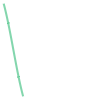

In [45]:
cpr_ls.intersection(tracking_bounds)

In [46]:
cpr_gdf = gpd.GeoDataFrame(
    data=[], 
    geometry=[
        shapely.Point(lon, lat) for lon, lat in zip(datasets["CPR_FMR_2A"].longitude, datasets["CPR_FMR_2A"].latitude)
    ], 
    crs="EPSG:4326"
)

In [47]:
cpr_gdf.sjoin(
    gpd.GeoDataFrame(geometry=[tracking_bounds], crs="EPSG:4326")
).drop("index_right", axis=1).index

Index([ 3207,  3208,  3209,  3210,  3211,  3212,  3213,  3214,  3215,  3216,
       ...
       11662, 11663, 11664, 11665, 11666, 11667, 11668, 11669, 11670, 11671],
      dtype='int64', length=8465)

In [48]:
datasets["CPR_FMR_2A"].isel(along_track=cpr_gdf.sjoin(
    gpd.GeoDataFrame(geometry=[tracking_bounds], crs="EPSG:4326")
).drop("index_right", axis=1).index)

<xarray.Dataset> Size: 34MB
Dimensions:                     (along_track: 8465, height: 200)
Coordinates:
    time                        (along_track) datetime64[ns] 68kB 2024-08-10T...
    latitude                    (along_track) float64 68kB -38.74 ... 38.75
    longitude                   (along_track) float64 68kB 30.52 30.52 ... 14.29
  * height                      (height) float64 2kB 1.995e+04 ... 50.0
Dimensions without coordinates: along_track
Data variables:
    surface_elevation           (along_track) float32 34kB 31.76 31.76 ... 42.74
    land_flag                   (along_track) float32 34kB 0.0 0.0 ... 0.0 0.0
    quality_status              (along_track, height) float32 7MB 1.0 ... 1.0
    reflectivity_error          (along_track, height) float32 7MB nan ... 0.2234
    reflectivity_corrected      (along_track, height) float32 7MB nan ... nan
    multiple_scattering_status  (along_track, height) float64 14MB 0.0 ... 0.0
    brightness_temperature      (along_track) float32 34kB 275.9 276.8 ... 283.0
Attributes:
    File_Name:         ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_...
    File_Description:  
    Notes:             Test Notes
    Mission:           EarthCARE
    File_Class:        EXBA
    File_Type:         CPR_FMR_2A
    File_Version:      0001

In [49]:
merged_ds = datasets["CPR_FMR_2A"].isel(along_track=cpr_gdf.sjoin(
    gpd.GeoDataFrame(geometry=[tracking_bounds], crs="EPSG:4326")
).drop("index_right", axis=1).index)

In [50]:
from sklearn.neighbors import BallTree
ec_ll_tree = BallTree(
    np.radians(np.stack(
        [
            merged_ds.latitude.values, 
            merged_ds.longitude.values,
        ], axis=1
    )), 
    metric="haversine", 
)

In [51]:
ec_ll = np.radians(np.stack(
    [
        merged_ds.latitude.values, 
        merged_ds.longitude.values,
    ], axis=1
))

In [52]:
rad_1km = np.radians(360)/4e4

In [53]:
xr.DataTree(merged_ds)

<xarray.DataTree>
Group: /
    Dimensions:                     (along_track: 8465, height: 200)
    Coordinates:
        time                        (along_track) datetime64[ns] 68kB 2024-08-10T...
        latitude                    (along_track) float64 68kB -38.74 ... 38.75
        longitude                   (along_track) float64 68kB 30.52 30.52 ... 14.29
      * height                      (height) float64 2kB 1.995e+04 ... 50.0
    Dimensions without coordinates: along_track
    Data variables:
        surface_elevation           (along_track) float32 34kB 31.76 31.76 ... 42.74
        land_flag                   (along_track) float32 34kB 0.0 0.0 ... 0.0 0.0
        quality_status              (along_track, height) float32 7MB 1.0 ... 1.0
        reflectivity_error          (along_track, height) float32 7MB nan ... 0.2234
        reflectivity_corrected      (along_track, height) float32 7MB nan ... nan
        multiple_scattering_status  (along_track, height) float64 14MB 0.0 ... 0.0
        brightness_temperature      (along_track) float32 34kB 275.9 276.8 ... 283.0
    Attributes:
        File_Name:         ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_...
        File_Description:  
        Notes:             Test Notes
        Mission:           EarthCARE
        File_Class:        EXBA
        File_Type:         CPR_FMR_2A
        File_Version:      0001

In [54]:
def colocate_earthcare(ds, locations):
    search_ll_tree = BallTree(
        np.radians(
            np.stack(
                [
                    ds.latitude.values, 
                    ds.longitude.values,
                ], axis=1
            )
        ), 
        metric="haversine", 
    )

    distances, neighbours = search_ll_tree.query(locations)

    return ds.isel(along_track=neighbours.ravel()).where(
        xr.DataArray(distances.ravel() < rad_1km, dims="along_track")
    )

In [55]:
merged_dt = xr.DataTree(
    dataset=xr.Dataset(coords=merged_ds.coords), 
    children={
        k:(xr.DataTree(colocate_earthcare(v, ec_ll)) if k!="CPR_FMR_2A" else xr.DataTree(merged_ds))
        for k, v in datasets.items()
    }
)

In [56]:
merged_dt

<xarray.DataTree>
Group: /
│   Dimensions:    (along_track: 8465, height: 200)
│   Coordinates:
│       time       (along_track) datetime64[ns] 68kB 2024-08-10T00:22:31.87749504...
│       latitude   (along_track) float64 68kB -38.74 -38.74 -38.73 ... 38.74 38.75
│       longitude  (along_track) float64 68kB 30.52 30.52 30.52 ... 14.3 14.3 14.29
│     * height     (height) float64 2kB 1.995e+04 1.985e+04 1.975e+04 ... 150.0 50.0
│   Dimensions without coordinates: along_track
├── Group: /CPR_CD__2A
│       Dimensions:                                                (along_track: 8465,
│                                                                   height: 200)
│       Coordinates:
│           time                                                   (along_track) datetime64[ns] 68kB ...
│           latitude                                               (along_track) float64 68kB ...
│           longitude                                              (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           quality_status                                         (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 7MB ...
│           doppler_velocity_best_estimate                         (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate                   (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_error             (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_status            (along_track, height) float32 7MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_CPR_CD__2A_20240810T001450Z_20250904T193109Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         CPR_CD__2A
│           File_Version:      0001
└── Group: /CPR_FMR_2A
        Dimensions:                     (along_track: 8465, height: 200)
        Coordinates:
            time                        (along_track) datetime64[ns] 68kB 2024-08-10T...
            latitude                    (along_track) float64 68kB -38.74 ... 38.75
            longitude                   (along_track) float64 68kB 30.52 30.52 ... 14.29
        Dimensions without coordinates: along_track
        Data variables:
            surface_elevation           (along_track) float32 34kB 31.76 31.76 ... 42.74
            land_flag                   (along_track) float32 34kB 0.0 0.0 ... 0.0 0.0
            quality_status              (along_track, height) float32 7MB 1.0 ... 1.0
            reflectivity_error          (along_track, height) float32 7MB nan ... 0.2234
            reflectivity_corrected      (along_track, height) float32 7MB nan ... nan
            multiple_scattering_status  (along_track, height) float64 14MB 0.0 ... 0.0
            brightness_temperature      (along_track) float32 34kB 275.9 276.8 ... 283.0
        Attributes:
            File_Name:         ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_...
            File_Description:  
            Notes:             Test Notes
            Mission:           EarthCARE
            File_Class:        EXBA
            File_Type:         CPR_FMR_2A
            File_Version:      0001

In [57]:
pd.date_range(
    pd.Timestamp(merged_dt.time.min().values).floor("1d"), 
    pd.Timestamp(merged_dt.time.max().values).floor("1d"), 
    freq="1d"
)

DatetimeIndex(['2024-08-10'], dtype='datetime64[ns]', freq='D')

In [58]:
track_mask_filenames = []
for d in pd.date_range(
    pd.Timestamp(merged_dt.time.min().values).floor("1d"), 
    pd.Timestamp(merged_dt.time.max().values).floor("1d"), 
    freq="1d"
):
    track_mask_filenames.extend(
        sorted(list(tracking_path.rglob(f'detected_dccs_*S{d.strftime("%Y%m%d_%H%M%S")}*.nc')))
    )

In [59]:
track_mask_filenames

[PosixPath('/gws/ssde/j25a/esaclim/will/orcestra_linked/2024/detected_dccs_MSG_S20240810_000000_E20240811_000000_X0044_3667_Y0712_2999.nc')]

In [60]:
tracks_ds = xr.open_mfdataset(
    track_mask_filenames, combine="nested", concat_dim="t", 
    preprocess=lambda ds: ds[["core_label", "thick_anvil_label", "thin_anvil_label"]]
)

In [61]:
tracks_ds

<xarray.Dataset> Size: 10GB
Dimensions:            (t: 96, y: 2287, x: 3623)
Coordinates:
  * t                  (t) datetime64[ns] 768B 2024-08-10T00:12:42.298000 ......
  * y                  (y) float64 18kB -3.429e+06 -3.426e+06 ... 3.429e+06
  * x                  (x) float64 29kB 5.434e+06 5.431e+06 ... -5.434e+06
    longitude          (y, x) float64 66MB dask.array<chunksize=(2287, 3623), meta=np.ndarray>
    latitude           (y, x) float64 66MB dask.array<chunksize=(2287, 3623), meta=np.ndarray>
Data variables:
    core_label         (t, y, x) int32 3GB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    thick_anvil_label  (t, y, x) int32 3GB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>
    thin_anvil_label   (t, y, x) int32 3GB dask.array<chunksize=(1, 50, 50), meta=np.ndarray>

In [62]:
import pyproj

In [63]:
proj = pyproj.Proj('+proj=geos +lon_0 +h=035785831.0 +x_0=0 +y_0=0')

In [64]:
x, y = proj(merged_dt.longitude, merged_dt.latitude,)

In [65]:
tracks_ds.sel(
    x=xr.DataArray(x, dims="along_track"), 
    y=xr.DataArray(y, dims="along_track"), 
    t=merged_dt.time,
    method="nearest",
).reset_coords(drop=True)

<xarray.Dataset> Size: 102kB
Dimensions:            (along_track: 8465)
Dimensions without coordinates: along_track
Data variables:
    core_label         (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
    thick_anvil_label  (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
    thin_anvil_label   (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>

In [66]:
tracks_ds.sel(
    x=xr.DataArray(x, dims="along_track"), 
    y=xr.DataArray(y, dims="along_track"), 
    t=merged_dt.time,
    method="nearest",
).data_vars.items()

ItemsView(Data variables:
    core_label         (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
    thick_anvil_label  (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
    thin_anvil_label   (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>)

In [67]:
for var, da in tracks_ds.sel(
    x=xr.DataArray(x, dims="along_track"), 
    y=xr.DataArray(y, dims="along_track"), 
    t=merged_dt.time,
    method="nearest",
).reset_coords(drop=True).data_vars.items():
    merged_dt[var] = da

In [68]:
merged_dt

<xarray.DataTree>
Group: /
│   Dimensions:            (along_track: 8465, height: 200)
│   Coordinates:
│       time               (along_track) datetime64[ns] 68kB 2024-08-10T00:22:31....
│       latitude           (along_track) float64 68kB -38.74 -38.74 ... 38.74 38.75
│       longitude          (along_track) float64 68kB 30.52 30.52 ... 14.3 14.29
│     * height             (height) float64 2kB 1.995e+04 1.985e+04 ... 150.0 50.0
│   Dimensions without coordinates: along_track
│   Data variables:
│       core_label         (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
│       thick_anvil_label  (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
│       thin_anvil_label   (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
├── Group: /CPR_CD__2A
│       Dimensions:                                                (along_track: 8465,
│                                                                   height: 200)
│       Coordinates:
│           time                                                   (along_track) datetime64[ns] 68kB ...
│           latitude                                               (along_track) float64 68kB ...
│           longitude                                              (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           quality_status                                         (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 7MB ...
│           doppler_velocity_best_estimate                         (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate                   (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_error             (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_status            (along_track, height) float32 7MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_CPR_CD__2A_20240810T001450Z_20250904T193109Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         CPR_CD__2A
│           File_Version:      0001
└── Group: /CPR_FMR_2A
        Dimensions:                     (along_track: 8465, height: 200)
        Coordinates:
            time                        (along_track) datetime64[ns] 68kB 2024-08-10T...
            latitude                    (along_track) float64 68kB -38.74 ... 38.75
            longitude                   (along_track) float64 68kB 30.52 30.52 ... 14.29
        Dimensions without coordinates: along_track
        Data variables:
            surface_elevation           (along_track) float32 34kB 31.76 31.76 ... 42.74
            land_flag                   (along_track) float32 34kB 0.0 0.0 ... 0.0 0.0
            quality_status              (along_track, height) float32 7MB 1.0 ... 1.0
            reflectivity_error          (along_track, height) float32 7MB nan ... 0.2234
            reflectivity_corrected      (along_track, height) float32 7MB nan ... nan
            multiple_scattering_status  (along_track, height) float64 14MB 0.0 ... 0.0
            brightness_temperature      (along_track) float32 34kB 275.9 276.8 ... 283.0
        Attributes:
            File_Name:         ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_...
            File_Description:  
            Notes:             Test Notes
            Mission:           EarthCARE
            File_Class:        EXBA
            File_Type:         CPR_FMR_2A
            File_Version:      0001

In [69]:
" ".join(granules)

'01136H 01137A 01137B'

In [70]:
merged_dt.attrs["track_mask_filenames"]=" ".join([f.name for f in track_mask_filenames])
merged_dt.attrs["granules"] = " ".join(granules)

In [71]:
merged_dt

<xarray.DataTree>
Group: /
│   Dimensions:            (along_track: 8465, height: 200)
│   Coordinates:
│       time               (along_track) datetime64[ns] 68kB 2024-08-10T00:22:31....
│       latitude           (along_track) float64 68kB -38.74 -38.74 ... 38.74 38.75
│       longitude          (along_track) float64 68kB 30.52 30.52 ... 14.3 14.29
│     * height             (height) float64 2kB 1.995e+04 1.985e+04 ... 150.0 50.0
│   Dimensions without coordinates: along_track
│   Data variables:
│       core_label         (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
│       thick_anvil_label  (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
│       thin_anvil_label   (along_track) int32 34kB dask.array<chunksize=(2500,), meta=np.ndarray>
│   Attributes:
│       track_mask_filenames:  detected_dccs_MSG_S20240810_000000_E20240811_00000...
│       granules:              01136H 01137A 01137B
├── Group: /CPR_CD__2A
│       Dimensions:                                                (along_track: 8465,
│                                                                   height: 200)
│       Coordinates:
│           time                                                   (along_track) datetime64[ns] 68kB ...
│           latitude                                               (along_track) float64 68kB ...
│           longitude                                              (along_track) float64 68kB ...
│       Dimensions without coordinates: along_track
│       Data variables:
│           quality_status                                         (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_error   (along_track, height) float32 7MB ...
│           doppler_velocity_and_spectrum_width_integrated_status  (along_track, height) float32 7MB ...
│           doppler_velocity_best_estimate                         (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate                   (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_error             (along_track, height) float32 7MB ...
│           sedimentation_velocity_best_estimate_status            (along_track, height) float32 7MB ...
│       Attributes:
│           File_Name:         ECA_EXBA_CPR_CD__2A_20240810T001450Z_20250904T193109Z_...
│           File_Description:  
│           Notes:             Test Notes
│           Mission:           EarthCARE
│           File_Class:        EXBA
│           File_Type:         CPR_CD__2A
│           File_Version:      0001
└── Group: /CPR_FMR_2A
        Dimensions:                     (along_track: 8465, height: 200)
        Coordinates:
            time                        (along_track) datetime64[ns] 68kB 2024-08-10T...
            latitude                    (along_track) float64 68kB -38.74 ... 38.75
            longitude                   (along_track) float64 68kB 30.52 30.52 ... 14.29
        Dimensions without coordinates: along_track
        Data variables:
            surface_elevation           (along_track) float32 34kB 31.76 31.76 ... 42.74
            land_flag                   (along_track) float32 34kB 0.0 0.0 ... 0.0 0.0
            quality_status              (along_track, height) float32 7MB 1.0 ... 1.0
            reflectivity_error          (along_track, height) float32 7MB nan ... 0.2234
            reflectivity_corrected      (along_track, height) float32 7MB nan ... nan
            multiple_scattering_status  (along_track, height) float64 14MB 0.0 ... 0.0
            brightness_temperature      (along_track) float32 34kB 275.9 276.8 ... 283.0
        Attributes:
            File_Name:         ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_...
            File_Description:  
            Notes:             Test Notes
            Mission:           EarthCARE
            File_Class:        EXBA
            File_Type:         CPR_FMR_2A
            F

In [72]:
" ".join([f.name for f in track_mask_filenames])

'detected_dccs_MSG_S20240810_000000_E20240811_000000_X0044_3667_Y0712_2999.nc'

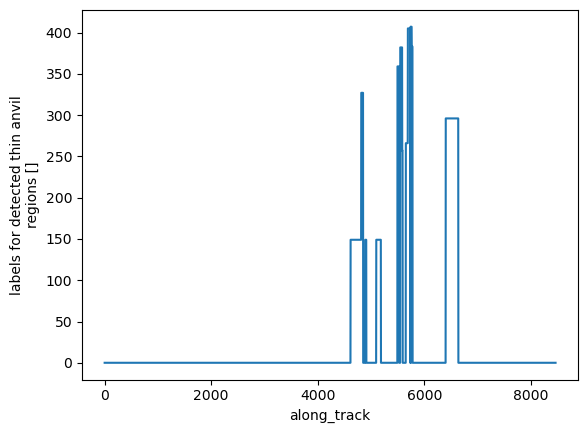

In [73]:
merged_dt.thin_anvil_label.plot()

In [76]:
comp = dict(zlib=True, complevel=5, shuffle=True)
for dt in merged_dt.descendants:
    for var in dt.data_vars:
        dt[var].encoding.update(comp)

In [78]:
dt.surface_elevation.encoding

{'chunksizes': (4991,),
 'fletcher32': False,
 'shuffle': True,
 'preferred_chunks': {'along_track': 4991},
 'zlib': True,
 'complevel': 5,
 'source': '<File-like object HTTPFileSystem, https://catalog.maap.eo.esa.int/data/earthcare-pdgs-01/EarthCARE/CPR_FMR_2A/BA/2024/08/10/ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_01136H/ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_01136H/ECA_EXBA_CPR_FMR_2A_20240810T001450Z_20250904T193109Z_01136H.h5>',
 'original_shape': (4991,),
 'dtype': dtype('<f4'),
 '_FillValue': 9.96921e+36}

In [ ]:
cpr_tracks = []

for idx, row in df.iterrows():
    with read_ec_file(row["stac"].assets.get('enclosure_h5').href) as ds:
        cpr_tracks.append(ds[["time", "latitude", "longitude"]].load())

cpr_df = pd.concat(
    [
        cpr_tracks[i].to_dataframe().assign(granule=df.loc[i].granule).set_index("granule", append=True).reorder_levels([1,0])
        for i in range(len(cpr_tracks))
    ]
)

cpr_gdf = gpd.GeoDataFrame(
    data=cpr_df, 
    geometry=[
        shapely.Point(lon, lat) for lon, lat in zip(cpr_df.longitude, cpr_df.latitude)
    ], 
    crs="EPSG:4326"
)

In [ ]:
cpr_gdf

In [ ]:
cpr_intersect_gdf = cpr_gdf.sjoin(
    gpd.GeoDataFrame(geometry=[tracking_bounds], crs="EPSG:4326")
).drop("index_right", axis=1)

In [ ]:
cpr_intersect_gdf

In [ ]:
cpr_intersect_gdf.plot()

In [139]:
[
    df for _, df in cpr_intersect_gdf.groupby((cpr_intersect_gdf.time.diff() > np.timedelta64(int(1e12), "ns")).cumsum())
][0].index

MultiIndex([('01331F', 3206),
            ('01331F', 3207),
            ('01331F', 3208),
            ('01331F', 3209),
            ('01331F', 3210),
            ('01331F', 3211),
            ('01331F', 3212),
            ('01331F', 3213),
            ('01331F', 3214),
            ('01331F', 3215),
            ...
            ('01329D', 1771),
            ('01329D', 1772),
            ('01329D', 1773),
            ('01329D', 1774),
            ('01329D', 1775),
            ('01329D', 1776),
            ('01329D', 1777),
            ('01329D', 1778),
            ('01329D', 1779),
            ('01329D', 1780)],
           names=['granule', 'along_track'], length=8465)

In [143]:
[
    df for _, df in cpr_intersect_gdf.groupby((cpr_intersect_gdf.time.diff() > np.timedelta64(int(1e12), "ns")).cumsum())
][0].index.get_level_values("granule").unique()

Index(['01331F', '01330F', '01329D'], dtype='object', name='granule')

In [144]:
[
    df.index.get_level_values("granule").unique() 
    for _, df in cpr_intersect_gdf.groupby((cpr_intersect_gdf.time.diff() > np.timedelta64(int(1e12), "ns")).cumsum())
]

[Index(['01331F', '01330F', '01329D'], dtype='object', name='granule'),
 Index(['01325H', '01326B', '01327B'], dtype='object', name='granule'),
 Index(['01325A', '01324B', '01338A'], dtype='object', name='granule'),
 Index(['01333D', '01334E', '01329F'], dtype='object', name='granule'),
 Index(['01326H'], dtype='object', name='granule'),
 Index(['01332F', '01333F', '01334F'], dtype='object', name='granule'),
 Index(['01335H', '01328A', '01328D'], dtype='object', name='granule'),
 Index(['01338H', '01336H', '01338B'], dtype='object', name='granule'),
 Index(['01337B', '01323H'], dtype='object', name='granule'),
 Index(['01324H', '01325B', '01329E'], dtype='object', name='granule'),
 Index(['01334D', '01330D', '01324A'], dtype='object', name='granule'),
 Index(['01331D', '01326A', '01328F'], dtype='object', name='granule'),
 Index(['01327A', '01337H', '01337A'], dtype='object', name='granule'),
 Index(['01333E'], dtype='object', name='granule')]

In [47]:
result = earthaccess.search_datasets(
    keyword="gpm"
)

In [71]:
result[0].get_umm("CollectionCitations")[0]["Title"]

'GMI 25km gridded SST data set'

In [59]:
result[0].summary()

/tmp/ipykernel_2536/2142732092.py:1: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  result[0].summary()


{'short-name': 'GMI-REMSS-L3U-v8.2a',
 'concept-id': 'C2036877762-POCLOUD',
 'version': '8.2a',
 'file-type': "[{'Format': 'netCDF-4', 'FormatType': 'Native'}]",
 'get-data': ['https://cmr.earthdata.nasa.gov/virtual-directory/collections/C2036877762-POCLOUD',
  'https://search.earthdata.nasa.gov/search/granules?p=C2036877762-POCLOUD',
  'https://github.com/podaac/data-subscriber'],
 'cloud-info': {'Region': 'us-west-2',
  'S3BucketAndObjectPrefixNames': ['podaac-ops-cumulus-protected/GMI-REMSS-L3U-v8.2a/',
   'podaac-ops-cumulus-public/GMI-REMSS-L3U-v8.2a/'],
  'S3CredentialsAPIEndpoint': 'https://archive.podaac.earthdata.nasa.gov/s3credentials',
  'S3CredentialsAPIDocumentationURL': 'https://archive.podaac.earthdata.nasa.gov/s3credentialsREADME'}}

In [104]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import time

result = earthaccess.search_datasets(
    keyword="gcom wind speed", 
    cloud_hosted=True
)

for i, r in enumerate(result):
    try:
        print(f'{i}: {r.get_umm("CollectionCitations")[0]["Title"]}, {r.summary()["short-name"]} V{r.version()}')
    except Exception:
        print(f'{i}: {result[0].summary()["short-name"]} V{r.version()}')
    time.sleep(1e-3)

0: AMSR-E/AMSR2 Unified L3 Global Daily Ascending/Descending .25x.25 deg Ocean Grids V001, AU_DyOcn V1
1: RSS CCMP 6-Hourly 10 Meter Surface Winds Level 4 Version 3.1, CCMP_WINDS_10M6HR_L4_V3.1 V3.1
2: AMSR-E/AMSR2 Unified L2B Global Swath Ocean Products V001, AU_Ocean V1
3: AMSR-E/AMSR2 Unified L3 Global Monthly Ascending/Descending .25x.25 deg Ocean Grids V001, AU_MoOcn V1
4: GHRSST Level 2P Global Subskin SST from the AMSR2, AMSR2-REMSS-L2P-v8.2 V8.2
5: GHRSST Level 2P Global Subskin NRT SST from the AMSR2, AMSR2-REMSS-L2P_RT-v8.2 V8.2
6: RSS CCMP Monthly 10 Meter Surface Winds Level 4 Version 3.1, CCMP_WINDS_10MMONTHLY_L4_V3.1 V3.1
7: GHRSST Level 3U Global Subskin SST from the AMSR2, AMSR2-REMSS-L3U-v8.2 V8.2
8: GHRSST Level 3U Global Subskin SST from the AMSR2, AMSR2-REMSS-L3U-v8a V8a
9: GHRSST Level 3U Global Subskin SST from the AMSR2, AMSR2-REMSS-L3U_RT-v8.2 V8.2
10: GHRSST Level 3U Global NRT Subskin SST from the AMSR2, AMSR2-REMSS-L3U_RT-v8a V8a
11: AMSR-E/AMSR2 Unified L3 G

In [121]:
results = earthaccess.search_data(
    short_name="AU_Ocean", 
    temporal=("2024-08-18", "2024-08-18"),
    bounding_box=tracking_bounds.bounds,
)

In [122]:
len(results)

17

In [116]:
fileobjects = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/34 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/34 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/34 [00:00<?, ?it/s]

In [118]:
fileobjects

[<File-like object HTTPFileSystem, https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Ocean/1/2024/08/18/AMSR_U2_L2_Ocean_V01_202408180027_D.he5>,
 <File-like object HTTPFileSystem, https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Ocean/1/2024/08/18/AMSR_U2_L2_Ocean_V01_202408180027_D.ph>,
 <File-like object HTTPFileSystem, https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Ocean/1/2024/08/18/AMSR_U2_L2_Ocean_V01_202408180206_D.he5>,
 <File-like object HTTPFileSystem, https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Ocean/1/2024/08/18/AMSR_U2_L2_Ocean_V01_202408180206_D.ph>,
 <File-like object HTTPFileSystem, https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Ocean/1/2024/08/18/AMSR_U2_L2_Ocean_V01_202408180345_D.he5>,
 <File-like object HTTPFileSystem, https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/AMSA/AU_Ocean/1

In [119]:
xr.open_datatree(fileobjects[0])

<xarray.DataTree>
Group: /
│   Attributes:
│       Conventions:  CF-1.6
│       history:      First version of the Ocean processing software for the unif...
│       institution:  NASA's AMSR Science Investigator-led Processing System (SIPS)
│       references:   Please cite these data as: Kummerow, C., R. Ferraro, and D....
│       source:       satellite observation
│       title:        AMSR-E/AMSR2 Unified L2B Global Swath Ocean Products
├── Group: /HDFEOS
│   ├── Group: /HDFEOS/ADDITIONAL
│   │   └── Group: /HDFEOS/ADDITIONAL/FILE_ATTRIBUTES
│   └── Group: /HDFEOS/SWATHS
│       └── Group: /HDFEOS/SWATHS/AMSR2_Level2_Ocean_Suite
│           ├── Group: /HDFEOS/SWATHS/AMSR2_Level2_Ocean_Suite/Data Fields
│           │       Dimensions:                 (npix: 196, nscans: 1975, ntime: 6)
│           │       Dimensions without coordinates: npix, nscans, ntime
│           │       Data variables:
│           │           ChiSquared              (npix, nscans) float32 2MB ...
│           │           ErrorLWP                (npix, nscans) float32 2MB ...
│           │           ErrorTPW                (npix, nscans) float32 2MB ...
│           │           ErrorWind               (npix, nscans) float32 2MB ...
│           │           LandPercentage          (npix, nscans) float32 2MB ...
│           │           LiquidWaterPath         (npix, nscans) float32 2MB ...
│           │           QualityFlag             (npix, nscans) float32 2MB ...
│           │           ReynoldsSST             (npix, nscans) float32 2MB ...
│           │           SunGlintAngle           (npix, nscans) float32 2MB ...
│           │           TimeHR                  (ntime, nscans) int16 24kB ...
│           │           TotalPrecipitableWater  (npix, nscans) float32 2MB ...
│           │           WindSpeed               (npix, nscans) float32 2MB ...
│           └── Group: /HDFEOS/SWATHS/AMSR2_Level2_Ocean_Suite/Geolocation Fields
│                   Dimensions:    (npix: 196, nscans: 1975)
│                   Dimensions without coordinates: npix, nscans
│                   Data variables:
│                       Latitude   (npix, nscans) float32 2MB ...
│                       Longitude  (npix, nscans) float32 2MB ...
│                       Time       (nscans) datetime64[ns] 16kB ...
└── Group: /HDFEOS INFORMATION
        Dimensions:           ()
        Data variables:
            CoreMetadata.0    |S6845 7kB ...
            StructMetadata.0  |S32000 32kB ...
        Attributes:
            HDFEOSVersion:  HDFEOS_5.1.16

In [123]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import time

result = earthaccess.search_datasets(
    keyword="nucaps", 
    cloud_hosted=True
)

for i, r in enumerate(result):
    try:
        print(f'{i}: {r.get_umm("CollectionCitations")[0]["Title"]}, {r.summary()["short-name"]} V{r.version()}')
    except Exception:
        print(f'{i}: {result[0].summary()["short-name"]} V{r.version()}')
    time.sleep(1e-3)

0: VIIRS/SNPP Level-2 Water Vapor Products 6-min Swath 750m, WATVP_L2_VIIRS_SNPP V1


In [124]:
results = earthaccess.search_data(
    short_name="WATVP_L2_VIIRS_SNPP", 
    temporal=("2024-08-18", "2024-08-18"),
    bounding_box=tracking_bounds.bounds,
)

In [125]:
fileobjects = earthaccess.open(results)

In [127]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import time

result = earthaccess.search_datasets(
    keyword="noaa-21 atms", 
    cloud_hosted=True
)

for i, r in enumerate(result):
    try:
        print(f'{i}: {r.get_umm("CollectionCitations")[0]["Title"]}, {r.summary()["short-name"]} V{r.version()}')
    except Exception:
        print(f'{i}: {result[0].summary()["short-name"]} V{r.version()}')
    time.sleep(1e-3)

0: GPM ATMS on NOAA-21 (GPROF) Radiometer Precipitation Profiling L3 1 month 0.25 degree x 0.25 degree V07, GPM_3GPROFNOAA21ATMS V07
1: GPM ATMS on NOAA-21 (GPROF) Climate-based Radiometer Precipitation Profiling L3 1 month 0.25 degree x 0.25 degree V08, GPM_3GPROFNOAA21ATMS_CLIM V08
2: GPM ATMS on NOAA-21 (GPROF) Climate-based Radiometer Precipitation Profiling L3 1 month 0.25 degree x 0.25 degree V07, GPM_3GPROFNOAA21ATMS_CLIM V07
3: GPM ATMS on NOAA-21 (GPROF) Radiometer Precipitation Profiling L3 1 day 0.25 degree x 0.25 degree V07, GPM_3GPROFNOAA21ATMS_DAY V07
4: GPM ATMS on NOAA-21 (GPROF) Climate-based Radiometer Precipitation Profiling L3 1 day 0.25 degree x 0.25 degree V08, GPM_3GPROFNOAA21ATMS_DAY_CLIM V08
5: GPM ATMS on NOAA-21 (GPROF) Climate-based Radiometer Precipitation Profiling L3 1 day 0.25 degree x 0.25 degree V07, GPM_3GPROFNOAA21ATMS_DAY_CLIM V07
6: GPM ATMS on NOAA-21 (GPROF) Radiometer Precipitation Profiling L2A 1.5 hours 17 km V08, GPM_2AGPROFNOAA21ATMS V08
7: 